In [3]:
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from qmhub.units import AMBER_HARTREE_TO_KCAL, AMBER_BOHR_TO_A

In [1]:
!pwd

/Users/van/cas9-figures/plots-cas9/qmmm/wt/ene_decomp


In [20]:
# fnames = ['../00/qmmm_b3lyp_6-31+gd_energy.npy', 
#           # '../00/qmmm_b3lyp_6-31++',          
#           # '../00/qmmm_pbe0_6-31gd_energy.npy', 
#           # '../00/qmmm_pbe0_6-31+gd_energy.npy', 
#           '../00/qmmm_wb97xd_6-31gd_energy.npy',
#           '../00/qmmm_wb97xd_6-31+gd_energy.npy']

fnames = ['../00/qmmm_b3lyp_6-31+gd_energy.npy', 
          '../00/qmmm_blyp_6-31gd_energy.npy', 
          '../00/qmmm_blyp_6-31+gd_energy.npy', 
          '../00/qmmm_wb97xd_631+gd_energy.npy'
         ]

In [24]:
for i in fnames:
    f = np.load(i)
    print(f.shape, len(f))

(249, 1) 249
(250, 1) 250
(250, 1) 250
(250, 1) 250


../00/qmmm_b3lyp_6-31+gd_energy.npy
../00/qmmm_blyp_6-31gd_energy.npy


ValueError: x and y must be the same size

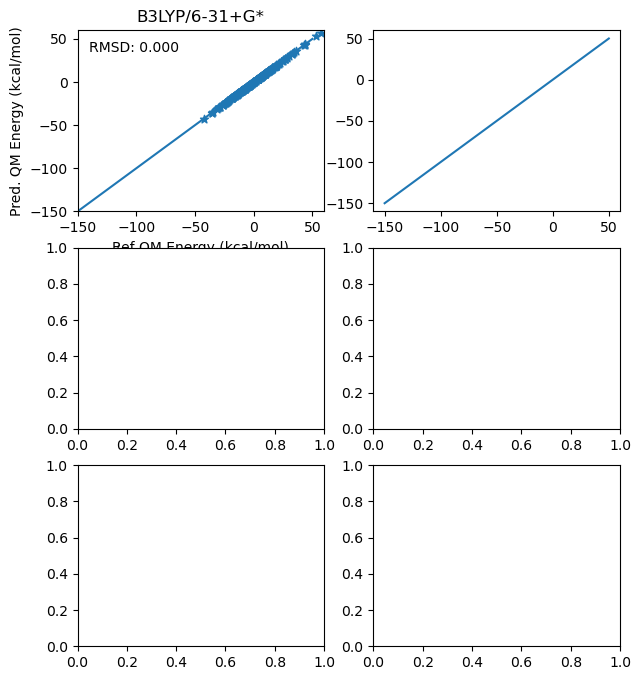

In [17]:
ref = np.load('../00/qmmm_b3lyp_6-31+gd_energy.npy') * 27.2114
ref_energy = (ref - ref.mean()) * 23.061

fig, axs = plt.subplots(3,2, figsize=(7,8))

for fname, ax in zip(fnames, axs.ravel()):
    print(fname)
    f = np.load(fname) * 27.2114
    f_energy = (f - f.mean()) * 23.061
    method = fname.split('_')[1].upper()
    basis = fname.split('_')[2].replace('d', '*').replace('p', '*')
    ax.plot([-150,50],[-150,50])
    ax.scatter(ref_energy, f_energy, marker='*')
    ax.set_xlabel('Ref QM Energy (kcal/mol)', fontsize=10)
    ax.set_ylabel('Pred. QM Energy (kcal/mol)', fontsize=10)
    ax.set_title('%s/%s' % (method.upper(), basis.upper()), fontsize=12)
    ax.set_xlim(-150, 60)
    ax.set_ylim(-150, 60)
    ax.text(-140, 35, 'RMSD: %.3f' % np.sqrt(np.mean((ref_energy - f_energy)**2)), size=10)

plt.tight_layout()
# plt.savefig('qmmm_energies_scatter.png', dpi=300)